In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("/Users/whatisanolive/Desktop/data-science/Unit2_EDA/smartphone_prices - smartphone_prices.csv")

In [4]:
df

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000
5,OnePlus,8,32000
6,Samsung,8,20000
7,Apple,8,50000
8,OnePlus,12,35000
9,Samsung,12,21000


<Axes: xlabel='price', ylabel='ram_gb'>

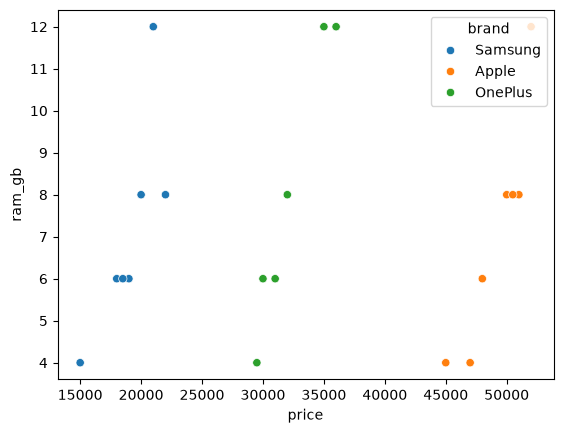

In [18]:
sns.scatterplot(data=df,x='price', y = 'ram_gb', hue='brand')

<Axes: xlabel='brand', ylabel='price'>

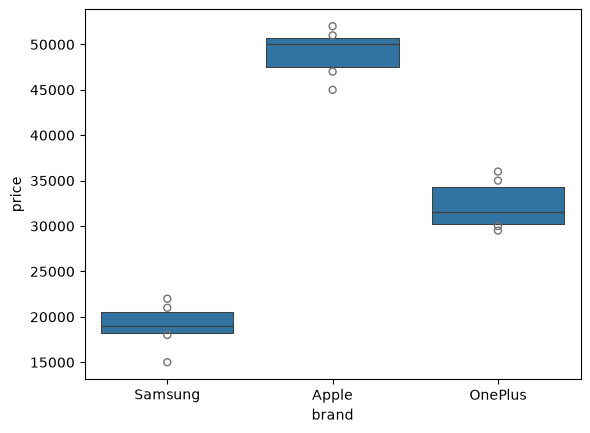

In [21]:
sns.boxenplot(data=df,x='brand',y='price')

In [6]:
print("Unique brands:", df['brand'].unique())

Unique brands: <StringArray>
['Samsung', 'Apple', 'OnePlus']
Length: 3, dtype: str


In [30]:
df_dummies = pd.get_dummies(df,columns=['brand'],dtype=int)

In [31]:
df.head()

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000


In [32]:
df_dummies.head()

,ram_gb,price,brand_Apple,brand_OnePlus,brand_Samsung
0,4,15000,0,0,1
1,4,45000,1,0,0
2,6,30000,0,1,0
3,6,18000,0,0,1
4,6,48000,1,0,0


In [33]:
df_dummies = df_dummies.drop('brand_Apple', axis=1)
df

,brand,ram_gb,price
0,Samsung,4,15000
1,Apple,4,45000
2,OnePlus,6,30000
3,Samsung,6,18000
4,Apple,6,48000
5,OnePlus,8,32000
6,Samsung,8,20000
7,Apple,8,50000
8,OnePlus,12,35000
9,Samsung,12,21000


,ram_gb,price,brand_Apple,brand_OnePlus,brand_Samsung
0,4,15000,0,0,1
1,4,45000,1,0,0
2,6,30000,0,1,0
3,6,18000,0,0,1
4,6,48000,1,0,0


In [11]:
X = df[['brand','ram_gb']]
y = df['price']

ct = ColumnTransformer([
    ('brand_ohe', OneHotEncoder(drop='first'), ['brand'])
], remainder='passthrough')

X_encoded = ct.fit_transform(X)
X_encoded[:5]

array([[0., 1., 4.],
       [0., 0., 4.],
       [1., 0., 6.],
       [0., 1., 6.],
       [0., 0., 6.]])

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [12]:
model2 = LinearRegression()
model2.fit(X_encoded, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-17485.89,-30000. , 775.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.353e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[12.04, 2.53, 1.5 ]"


In [13]:
print('Model coefficient: ', model2.coef_)
print('Model intercept: ', model2.intercept_)
print('r2 score: ', model2.score(X_encoded,y))

Model coefficient:  [-17485.88709677 -30000.            775.2016129 ]
Model intercept:  43534.27419354839
r2 score:  0.9941429785635915


In [36]:
pred_new = model2.predict([[1,0,0]])
print(pred_new)

[26048.38709677]


In [39]:
pred_new = model2.predict([[1,0,32]])
print(pred_new)

[50854.83870968]
